In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, log_loss, brier_score_loss
)
from load_data import load_modality_data
from modality_eval import evaluate_cross_modality, evaluate_within_modality
import numpy as np
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, 
                           matthews_corrcoef, confusion_matrix)
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

### Cross-modality

#### Parameters

In [ ]:
base_dir = 'h5_sep'
subjects = [2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28]
font = '1F'
condition = 'Par' #put 'Par' for parity, 'C1' for control

#### Digits → Number Words

In [ ]:
dig_to_words = evaluate_cross_modality(base_dir, subjects, 'Dig', 'NumWo')
print(dig_to_words)

              precision    recall  f1-score   support

        Even       0.51      0.48      0.49      1610
         Odd       0.51      0.55      0.53      1610

    accuracy                           0.51      3220
   macro avg       0.51      0.51      0.51      3220
weighted avg       0.51      0.51      0.51      3220



#### Number Words → Digits

In [4]:
words_to_dig = evaluate_cross_modality(base_dir, subjects, 'NumWo', 'Dig')
print(words_to_dig)

              precision    recall  f1-score   support

        Even       0.51      0.41      0.46      1610
         Odd       0.51      0.60      0.55      1610

    accuracy                           0.51      3220
   macro avg       0.51      0.51      0.50      3220
weighted avg       0.51      0.51      0.50      3220



#### Plotting diagnostics


Digits→Words Performance:
Accuracy: 0.502 (Chance: 0.5)
Balanced Accuracy: 0.502
ROC AUC: 0.503
Matthews CC: 0.005
Support: 3220 samples


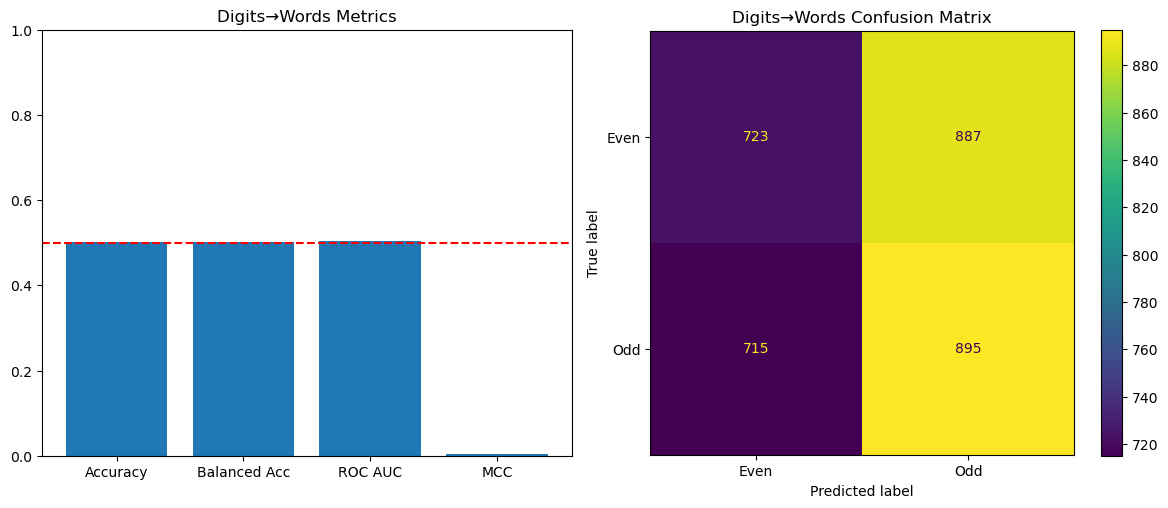


Words→Digits Performance:
Accuracy: 0.503 (Chance: 0.5)
Balanced Accuracy: 0.503
ROC AUC: 0.504
Matthews CC: 0.006
Support: 3220 samples


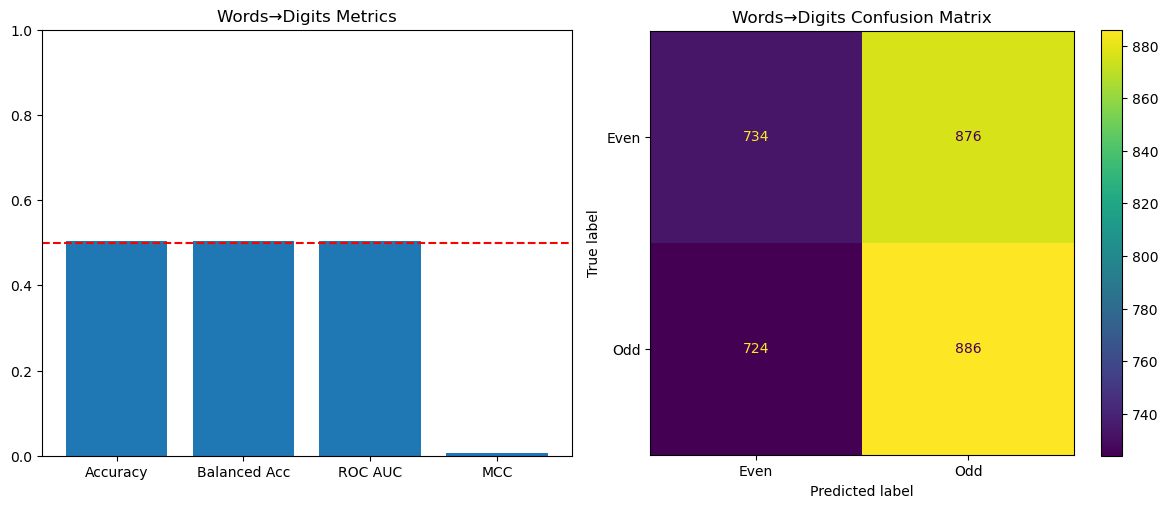

In [ ]:
def plot_diagnostics(metrics, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    ax[0].bar(['Accuracy', 'Balanced Acc', 'ROC AUC', 'MCC'],
             [metrics['accuracy'], metrics['balanced_accuracy'],
             metrics['roc_auc'], metrics['mcc']])
    ax[0].set_ylim(0, 1)
    ax[0].axhline(0.5, color='red', linestyle='--')
    ax[0].set_title(f'{title} Metrics')
    
    disp = ConfusionMatrixDisplay(metrics['confusion_matrix'],
                                display_labels=['Even', 'Odd'])
    disp.plot(ax=ax[1])
    ax[1].set_title(f'{title} Confusion Matrix')
    
    plt.tight_layout()
    plt.show()

for name, result in [('Digits→Words', dig_to_words), 
                    ('Words→Digits', words_to_dig)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
    else:
        print(f"\n{name}: No data available")

#### Null-model comparison

In [25]:
for modality in ['Dig', 'NumWo']:
    X, y, _ = load_modality_data(base_dir, subjects, modality)
    if not X.empty:
        null_acc = max(y.mean(), 1 - y.mean()) 
        print(f"{modality} null accuracy: {null_acc:.3f}")

Dig null accuracy: 0.500
NumWo null accuracy: 0.500


### Within-modality

#### Parameters

In [ ]:
base_dir = 'h5_sep'
subjects = [2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28]
font = '1F'
condition = 'Par' #put 'Par' for parity, 'C1' for control

#### Digits

In [7]:
dig_results = evaluate_within_modality(base_dir, subjects, 'Dig')
print(dig_results)

              precision    recall  f1-score   support

        Even       0.78      0.77      0.78      1610
         Odd       0.77      0.78      0.78      1610

    accuracy                           0.78      3220
   macro avg       0.78      0.78      0.78      3220
weighted avg       0.78      0.78      0.78      3220



#### Number Words (Within Modality)

In [8]:
numwo_results = evaluate_within_modality(base_dir, subjects, 'NumWo')
print(numwo_results)

              precision    recall  f1-score   support

        Even       0.77      0.80      0.79      1610
         Odd       0.79      0.77      0.78      1610

    accuracy                           0.78      3220
   macro avg       0.78      0.78      0.78      3220
weighted avg       0.78      0.78      0.78      3220



#### Plotting diagnostics


Digits Performance:
Accuracy: 0.922 (Chance: 0.5)
Balanced Accuracy: 0.922
ROC AUC: 0.982
Matthews CC: 0.844
Support: 3220 samples


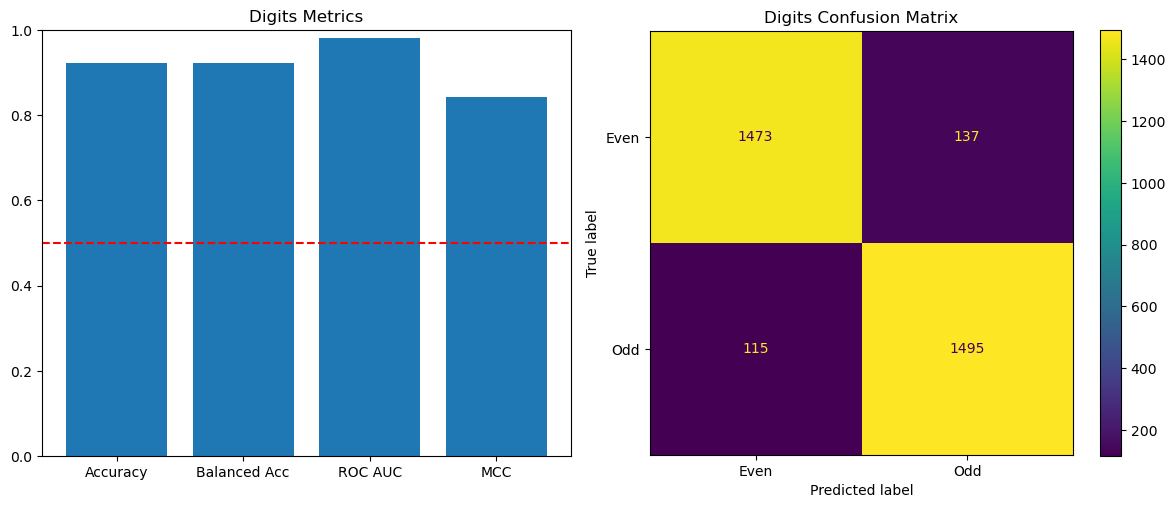


Number Words Performance:
Accuracy: 0.925 (Chance: 0.5)
Balanced Accuracy: 0.925
ROC AUC: 0.979
Matthews CC: 0.849
Support: 3220 samples


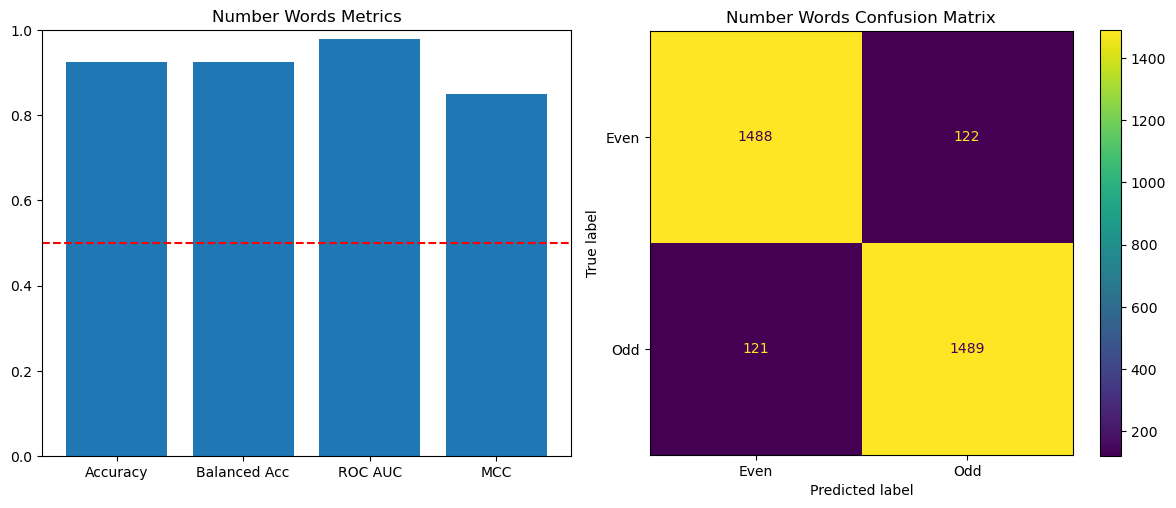

In [ ]:
def plot_diagnostics(metrics, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    ax[0].bar(['Accuracy', 'Balanced Acc', 'ROC AUC', 'MCC'],
             [metrics['accuracy'], metrics['balanced_accuracy'],
             metrics['roc_auc'], metrics['mcc']])
    ax[0].set_ylim(0, 1)
    ax[0].axhline(0.5, color='red', linestyle='--')
    ax[0].set_title(f'{title} Metrics')
    
    disp = ConfusionMatrixDisplay(metrics['confusion_matrix'],
                                display_labels=['Even', 'Odd'])
    disp.plot(ax=ax[1])
    ax[1].set_title(f'{title} Confusion Matrix')
    
    plt.tight_layout()
    plt.show()

for name, result in [('Digits', dig_results), 
                    ('Number Words', numwo_results)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
    else:
        print(f"\n{name}: No data available")

#### Null Model Comparison

In [11]:
for modality in ['Dig', 'NumWo']:
    X, y, _ = load_modality_data(base_dir, subjects, modality)
    if not X.empty:
        null_acc = max(y.mean(), 1 - y.mean()) 
        print(f"{modality} null accuracy: {null_acc:.3f}")

Dig null accuracy: 0.500
NumWo null accuracy: 0.500
